# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [2]:
import pandas as pd
import numpy as np

In [3]:
cars_df = pd.read_csv('data/vehicles.csv')

In [4]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
cars_df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [6]:
cars_df.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [7]:
cars_df.duplicated().sum()

np.int64(0)

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [8]:
# drop columns which has too many unique numbers
cars_clean = cars_df.drop({'id','VIN','region', 'model'},axis=1)
# remove rows that has missing manufacturer or year
cars_clean = cars_clean.dropna(subset=['manufacturer','year','odometer'], how = 'any')
# drop rows that price is missing (or equal to 0)
cars_clean = cars_clean[cars_clean['price'] != 0]

# fill null with 'unknown'
cars_clean['condition'] = cars_clean['condition'].fillna('unknown_condition')
cars_clean['cylinders'] = cars_clean['cylinders'].fillna('unknown_cyl')
cars_clean['fuel']=cars_clean['fuel'].fillna('unknown_fuel')
# cars_clean['odometer']=cars_clean['odometer'].fillna('unknown_odo')
cars_clean['title_status']=cars_clean['title_status'].fillna('unknown_title')
cars_clean['transmission']=cars_clean['transmission'].fillna('unknown_trans')
cars_clean['drive']=cars_clean['drive'].fillna('unknown_drive')
cars_clean['size']=cars_clean['size'].fillna('unknown_size')
cars_clean['type']=cars_clean['type'].fillna('unknown_type')
cars_clean['paint_color']=cars_clean['paint_color'].fillna('unknown_color')
cars_clean.isna().sum()

price           0
year            0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
size            0
type            0
paint_color     0
state           0
dtype: int64

In [9]:
cars_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 375619 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         375619 non-null  int64  
 1   year          375619 non-null  float64
 2   manufacturer  375619 non-null  object 
 3   condition     375619 non-null  object 
 4   cylinders     375619 non-null  object 
 5   fuel          375619 non-null  object 
 6   odometer      375619 non-null  float64
 7   title_status  375619 non-null  object 
 8   transmission  375619 non-null  object 
 9   drive         375619 non-null  object 
 10  size          375619 non-null  object 
 11  type          375619 non-null  object 
 12  paint_color   375619 non-null  object 
 13  state         375619 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 43.0+ MB


In [10]:
# change the type of data 
cars_clean['manufacturer'] = cars_clean['manufacturer'].astype('string')
cars_clean['condition'] = cars_clean['condition'].astype('string')
cars_clean['cylinders'] = cars_clean['cylinders'].astype('string')
cars_clean['fuel'] = cars_clean['fuel'].astype('string')
cars_clean['title_status'] = cars_clean['title_status'].astype('string')
cars_clean['transmission'] = cars_clean['transmission'].astype('string')
cars_clean['drive'] = cars_clean['drive'].astype('string')
cars_clean['size'] = cars_clean['size'].astype('string')
cars_clean['type'] = cars_clean['type'].astype('string')
cars_clean['paint_color'] = cars_clean['paint_color'].astype('string')
cars_clean['state'] = cars_clean['state'].astype('string')

In [11]:
cars_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 375619 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         375619 non-null  int64  
 1   year          375619 non-null  float64
 2   manufacturer  375619 non-null  string 
 3   condition     375619 non-null  string 
 4   cylinders     375619 non-null  string 
 5   fuel          375619 non-null  string 
 6   odometer      375619 non-null  float64
 7   title_status  375619 non-null  string 
 8   transmission  375619 non-null  string 
 9   drive         375619 non-null  string 
 10  size          375619 non-null  string 
 11  type          375619 non-null  string 
 12  paint_color   375619 non-null  string 
 13  state         375619 non-null  string 
dtypes: float64(2), int64(1), string(11)
memory usage: 43.0 MB


In [12]:
cars_clean.describe()

,price,year,odometer
count,3.756190e+05,375619.000000,3.756190e+05
mean,8.378142e+04,2011.287331,9.743813e+04
std,1.298382e+07,9.115793,1.936878e+05
min,1.000000e+00,1900.000000,0.000000e+00
25%,7.300000e+03,2008.000000,3.826450e+04
50%,1.549500e+04,2013.000000,8.715900e+04
75%,2.759000e+04,2017.000000,1.350490e+05
max,3.736929e+09,2022.000000,1.000000e+07


In [13]:
df_string=cars_clean.select_dtypes(exclude=['int','float'])
for col in df_string.columns:
    print(df_string[col].value_counts(),'\n')

manufacturer
ford               64542
chevrolet          50280
toyota             31387
honda              19753
jeep               17351
nissan             17291
ram                16390
gmc                15313
bmw                13690
dodge              12297
mercedes-benz      10276
hyundai             9320
subaru              8964
volkswagen          8843
lexus               7696
kia                 7526
audi                7150
cadillac            6550
acura               5686
chrysler            5622
buick               5159
mazda               5020
infiniti            4461
lincoln             4014
volvo               3269
mitsubishi          3107
mini                2255
pontiac             2226
rover               1978
jaguar              1900
porsche             1296
mercury             1137
saturn              1070
alfa-romeo           866
tesla                846
fiat                 771
harley-davidson      138
ferrari               81
datsun                63
aston-martin

In [14]:
from sklearn import preprocessing
le=preprocessing.LabelEncoder()
df_encode = cars_clean.copy()
#create a encoder for each string feature and print out the legend of each encription

for col in df_string.columns:
    df_encode[col] = le.fit_transform(df_encode[col])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    # print(le_name_mapping)
    print('\n############################\n')


############################


############################


############################


############################


############################


############################


############################


############################


############################


############################


############################



In [15]:
df_encode

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
27,33590,2014.0,14,2,6,2,57923.0,0,2,3,4,8,11,1
28,22590,2010.0,7,2,6,2,71229.0,0,2,3,4,8,1,1
29,39590,2020.0,7,2,6,2,19160.0,0,2,3,4,8,8,1
30,30990,2017.0,39,2,6,2,41124.0,0,2,3,4,8,8,1
31,15000,2013.0,13,0,5,2,128000.0,0,0,2,1,10,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,2019.0,31,2,5,2,32226.0,0,2,1,4,9,10,50
426876,30590,2020.0,41,2,8,2,12029.0,0,2,1,4,9,8,50
426877,34990,2020.0,6,2,8,0,4174.0,0,2,3,4,4,11,50
426878,28990,2018.0,23,2,5,2,30112.0,0,2,1,4,9,9,50


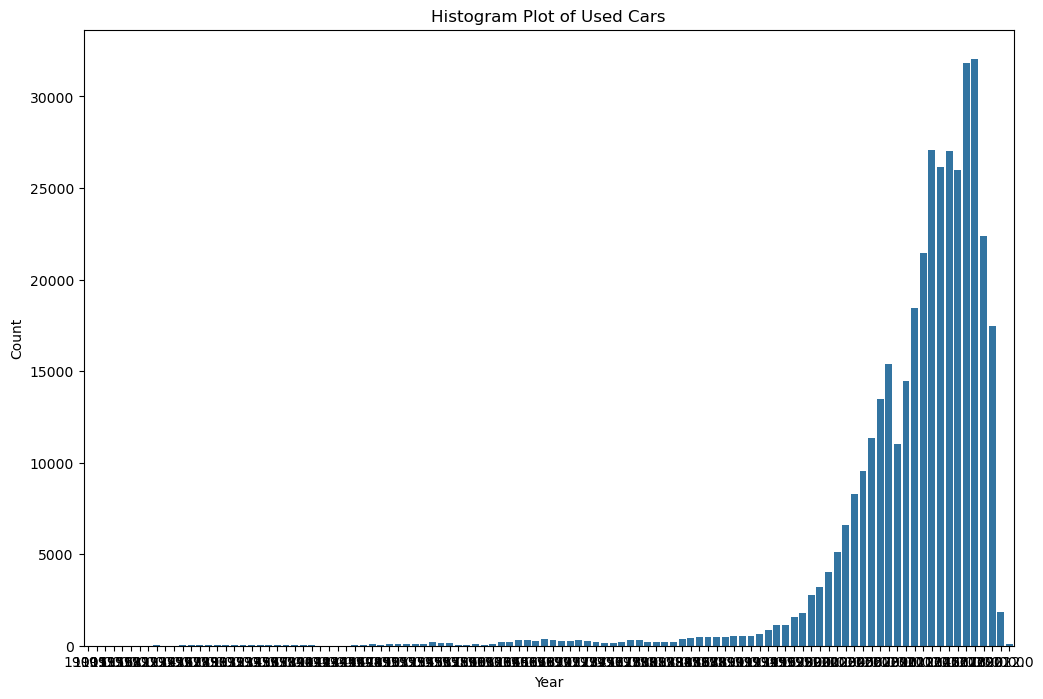

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,ax = plt.subplots(figsize=(12,8))
ax = sns.countplot(x='year', data=df_encode)
ax.set_title("Histogram Plot of Used Cars")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.show()

C:\Users\JPM\AppData\Local\Temp\ipykernel_20232\4206044415.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encode['odometer']).set(title="Histogram Plot of odometers")


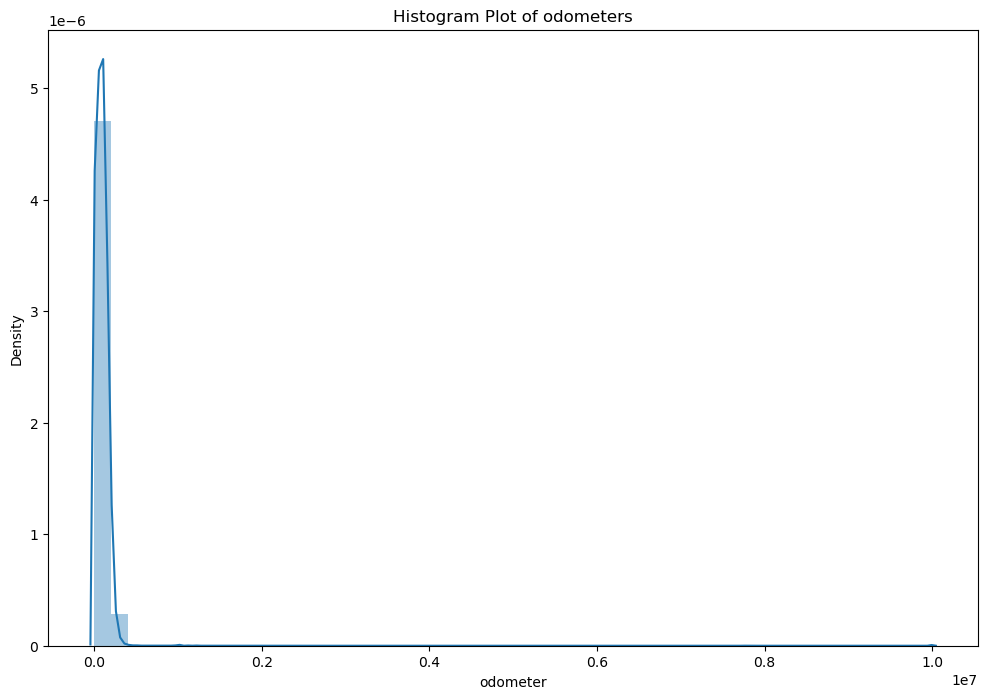

In [17]:
fig,ax = plt.subplots(figsize=(12,8))
sns.distplot(df_encode['odometer']).set(title="Histogram Plot of odometers")
plt.show()

C:\Users\JPM\AppData\Local\Temp\ipykernel_20232\3506956432.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encode['price']).set(title="Histogram Plot of price")


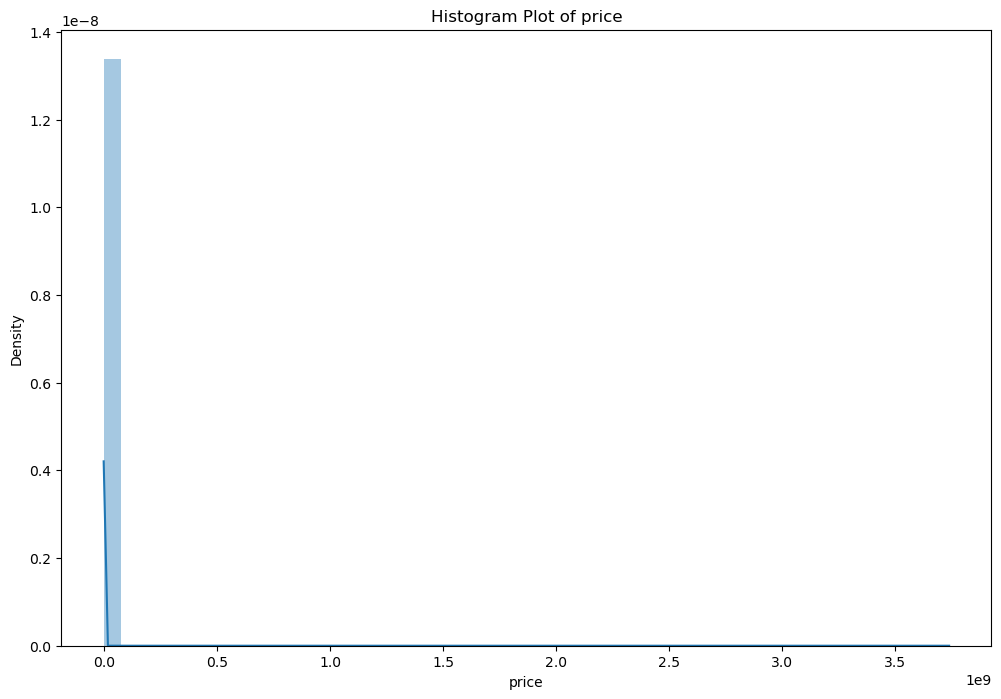

In [18]:
fig,ax = plt.subplots(figsize=(12,8))
sns.distplot(df_encode['price']).set(title="Histogram Plot of price")
plt.show()

In [19]:
print(df_encode['price'].min(), df_encode['price'].mean(), df_encode['price'].max(), df_encode['price'].std())

1 83781.4214669652 3736928711 12983816.664632505


In [20]:
print(df_encode['year'].min(), df_encode['year'].mean(), df_encode['year'].max(), df_encode['year'].std())

1900.0 2011.287331045554 2022.0 9.115793452341318


In [21]:
print(df_encode['odometer'].min(), df_encode['odometer'].mean(), df_encode['odometer'].max(), df_encode['odometer'].std())

0.0 97438.12786893101 10000000.0 193687.8314400818


There are outliners in the above three distributions.  it is making sense to drop the 3x sigma outliners

In [22]:
# drop the years which is less than mean - 3x std
df_encode=df_encode[(df_encode['year']> (df_encode['year'].mean() - 3*df_encode['year'].std()))]

# drop the odometer which is more than mean + 3x std
df_encode=df_encode[(df_encode['odometer']< (df_encode['odometer'].mean() + 3*df_encode['odometer'].std()))]

# drop the price which is more than mean + 3x std
df_encode=df_encode[(df_encode['price']< (df_encode['price'].mean() + 3*df_encode['price'].std()))]

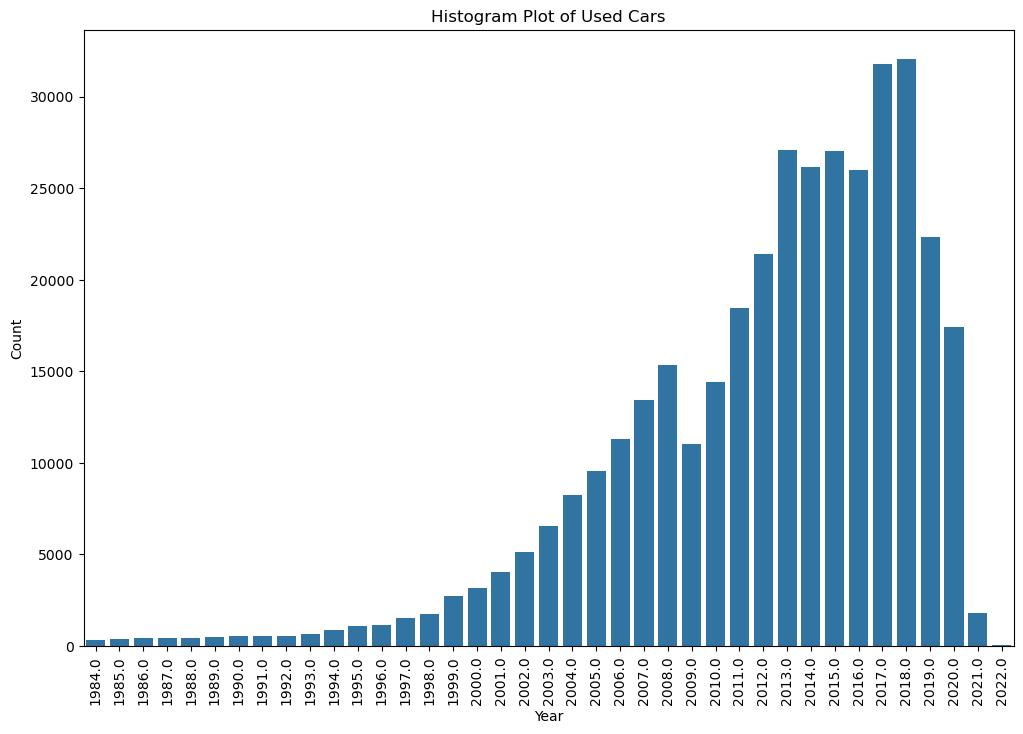

In [23]:
fig,ax = plt.subplots(figsize=(12,8))
ax = sns.countplot(x='year', data=df_encode)
ax.set_title("Histogram Plot of Used Cars")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.xticks(rotation=90)
plt.show()

C:\Users\JPM\AppData\Local\Temp\ipykernel_20232\4206044415.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encode['odometer']).set(title="Histogram Plot of odometers")


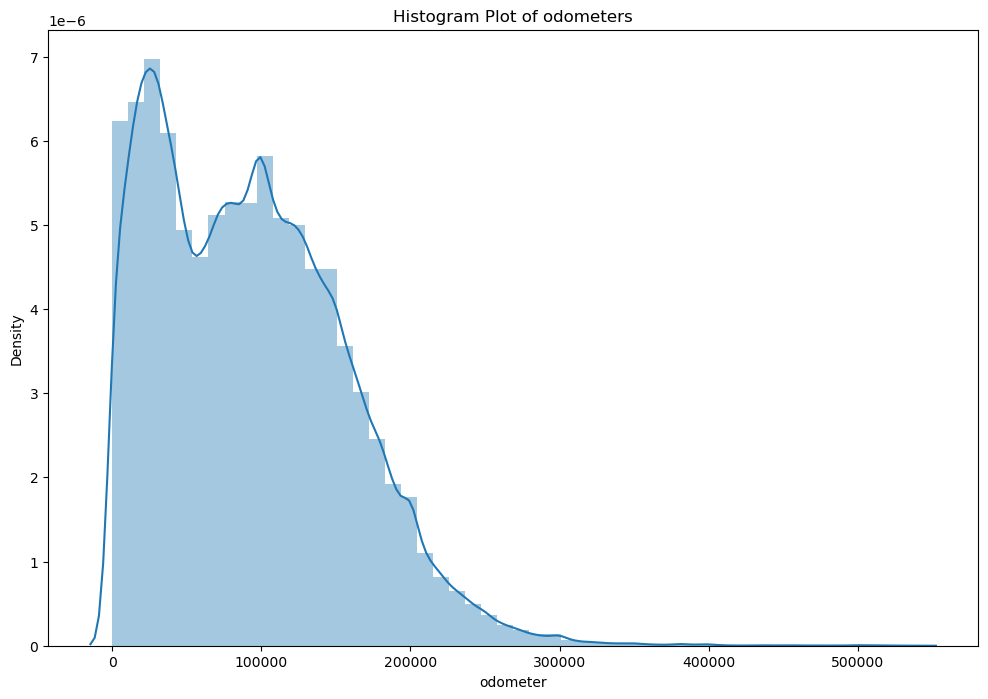

In [24]:
fig,ax = plt.subplots(figsize=(12,8))
sns.distplot(df_encode['odometer']).set(title="Histogram Plot of odometers")
plt.show()

C:\Users\JPM\AppData\Local\Temp\ipykernel_20232\3506956432.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encode['price']).set(title="Histogram Plot of price")


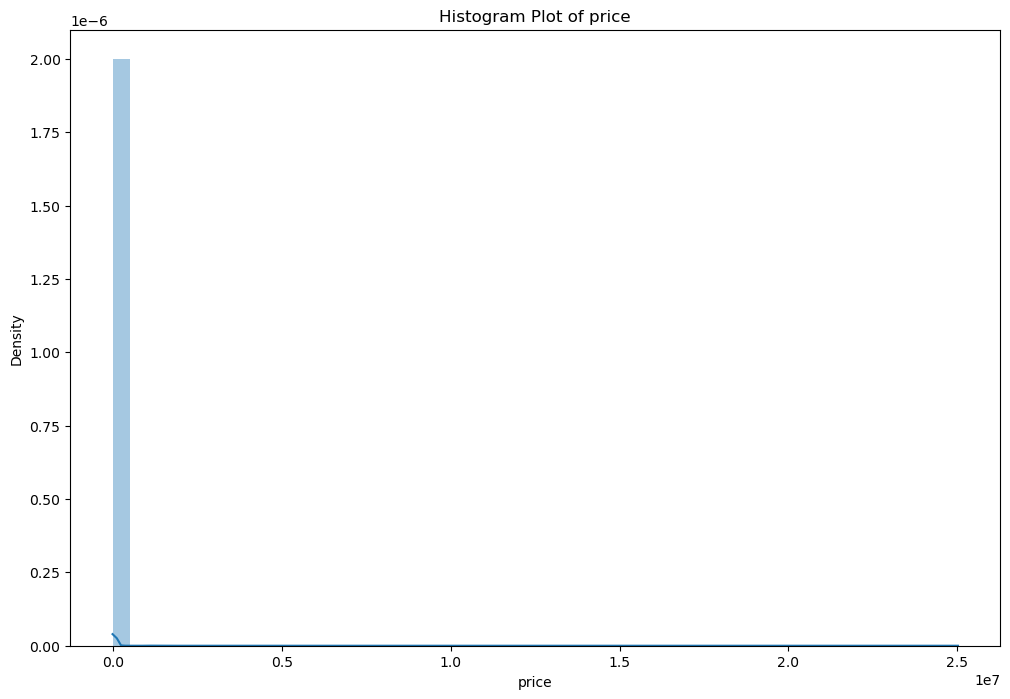

In [25]:
fig,ax = plt.subplots(figsize=(12,8))
sns.distplot(df_encode['price']).set(title="Histogram Plot of price")
plt.show()

Seems there is still a lot of outliners.  So let's make another round of removing outliners

In [26]:
# drop the years which is less than mean - 3x std
df_encode=df_encode[(df_encode['year']> (df_encode['year'].mean() - 3*df_encode['year'].std()))]

# drop the odometer which is more than mean + 3x std
df_encode=df_encode[(df_encode['odometer']< (df_encode['odometer'].mean() + 3*df_encode['odometer'].std()))]

# drop the price which is more than mean + 3x std
df_encode=df_encode[(df_encode['price']< (df_encode['price'].mean() + 3*df_encode['price'].std()))]

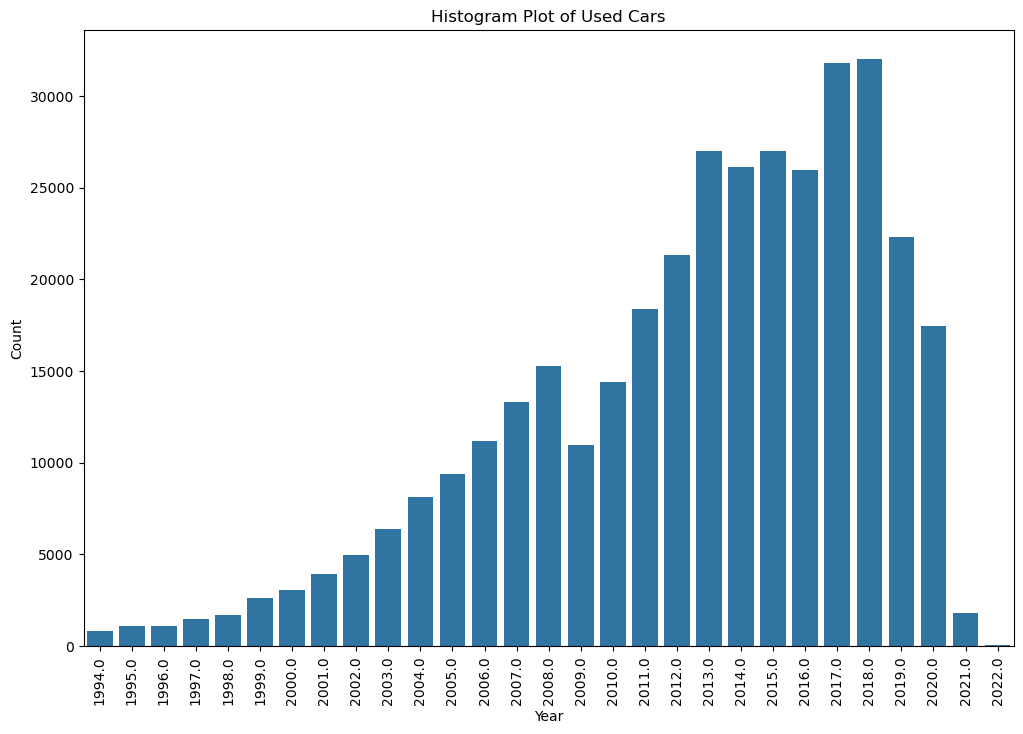

In [27]:
fig,ax = plt.subplots(figsize=(12,8))
ax = sns.countplot(x='year', data=df_encode)
ax.set_title("Histogram Plot of Used Cars")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.xticks(rotation=90)
plt.show()

C:\Users\JPM\AppData\Local\Temp\ipykernel_20232\4206044415.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encode['odometer']).set(title="Histogram Plot of odometers")


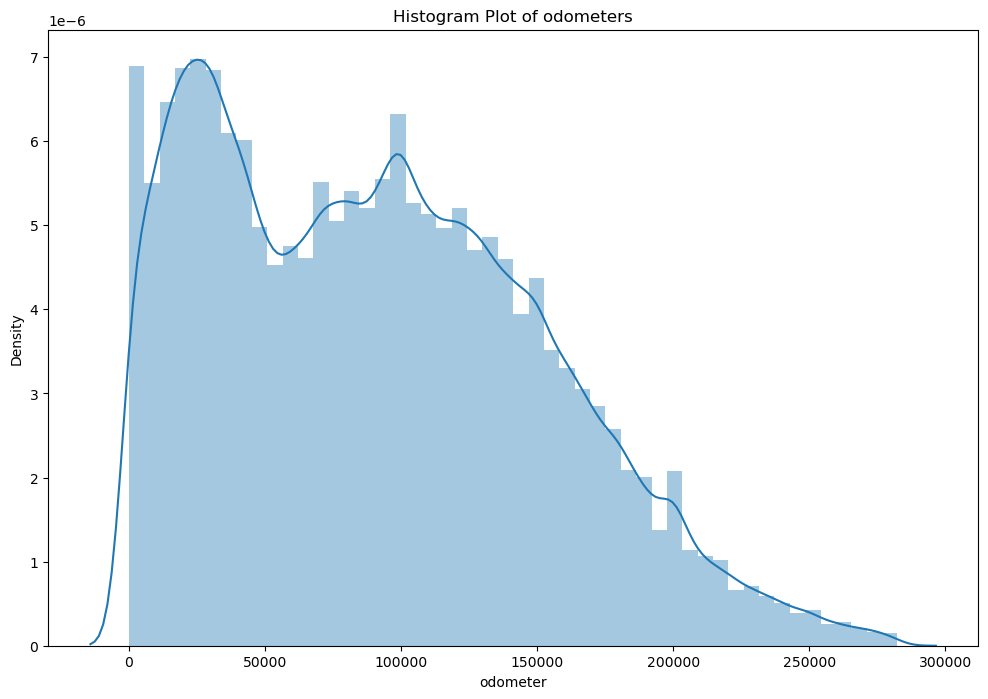

In [28]:
fig,ax = plt.subplots(figsize=(12,8))
sns.distplot(df_encode['odometer']).set(title="Histogram Plot of odometers")
plt.show()

C:\Users\JPM\AppData\Local\Temp\ipykernel_20232\3506956432.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encode['price']).set(title="Histogram Plot of price")


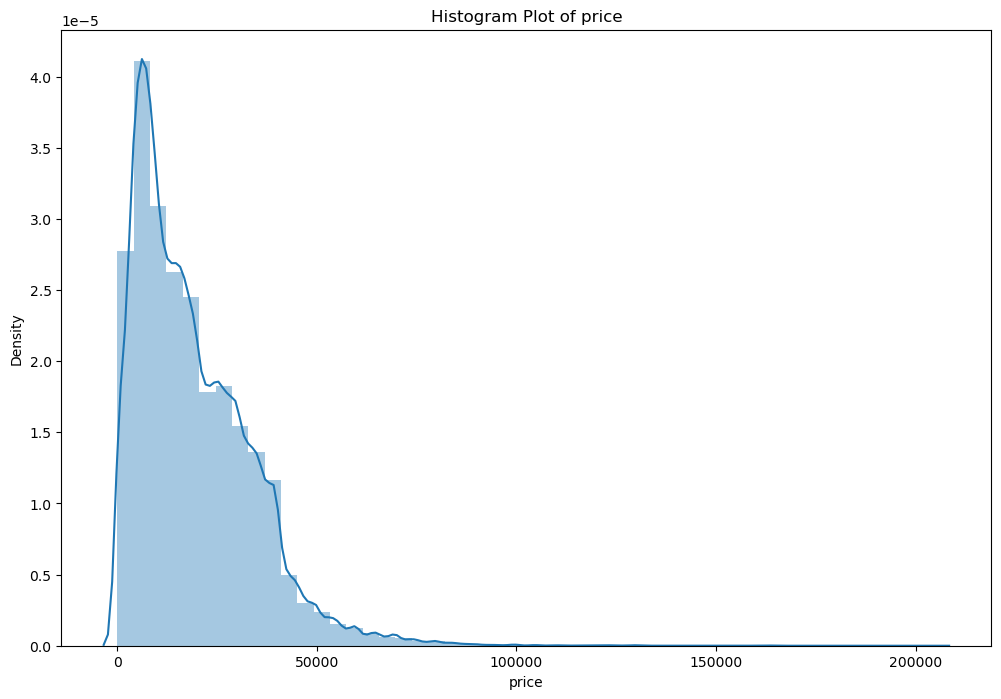

In [29]:
fig,ax = plt.subplots(figsize=(12,8))
sns.distplot(df_encode['price']).set(title="Histogram Plot of price")
plt.show()

In [30]:
df_encode.shape

(360851, 14)

In [31]:
df_encode

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
27,33590,2014.0,14,2,6,2,57923.0,0,2,3,4,8,11,1
28,22590,2010.0,7,2,6,2,71229.0,0,2,3,4,8,1,1
29,39590,2020.0,7,2,6,2,19160.0,0,2,3,4,8,8,1
30,30990,2017.0,39,2,6,2,41124.0,0,2,3,4,8,8,1
31,15000,2013.0,13,0,5,2,128000.0,0,0,2,1,10,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,2019.0,31,2,5,2,32226.0,0,2,1,4,9,10,50
426876,30590,2020.0,41,2,8,2,12029.0,0,2,1,4,9,8,50
426877,34990,2020.0,6,2,8,0,4174.0,0,2,3,4,4,11,50
426878,28990,2018.0,23,2,5,2,30112.0,0,2,1,4,9,9,50


In [32]:
df_encode.corr()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
price,1.000000,0.567671,-0.054044,0.100454,0.218814,-0.058559,-0.528110,-0.086785,0.255388,-0.082022,0.172931,-0.016818,-0.006517,0.017982
year,0.567671,1.000000,-0.018590,0.096646,0.103970,0.143574,-0.663797,0.005127,0.282394,-0.014110,0.189604,-0.051300,-0.016338,0.010214
manufacturer,-0.054044,-0.018590,1.000000,-0.002172,-0.078467,-0.024749,0.026916,0.014395,-0.000849,-0.080854,0.001818,0.034260,0.005742,-0.013904
condition,0.100454,0.096646,-0.002172,1.000000,0.284663,-0.024719,-0.024336,-0.097447,-0.162640,0.110975,0.262788,0.123487,0.097450,0.032772
cylinders,0.218814,0.103970,-0.078467,0.284663,1.000000,0.084860,-0.105107,-0.115425,0.165548,0.281333,0.343205,0.153558,0.113107,0.026529
fuel,-0.058559,0.143574,-0.024749,-0.024719,0.084860,1.000000,-0.180118,-0.003680,0.260864,0.113895,0.107721,-0.108325,-0.053619,-0.020458
odometer,-0.528110,-0.663797,0.026916,-0.024336,-0.105107,-0.180118,1.000000,-0.005832,-0.390969,-0.063129,-0.187244,0.065586,0.029226,0.007401
title_status,-0.086785,0.005127,0.014395,-0.097447,-0.115425,-0.003680,-0.005832,1.000000,-0.065135,0.015396,0.018026,-0.012841,0.053731,-0.000822
transmission,0.255388,0.282394,-0.000849,-0.162640,0.165548,0.260864,-0.390969,-0.065135,1.000000,0.150311,0.226266,-0.066500,-0.047838,-0.008089
drive,-0.082022,-0.014110,-0.080854,0.110975,0.281333,0.113895,-0.063129,0.015396,0.150311,1.000000,0.213825,0.199120,0.135811,-0.045424


Text(0.5, 1.0, 'Heatmap of correlation')

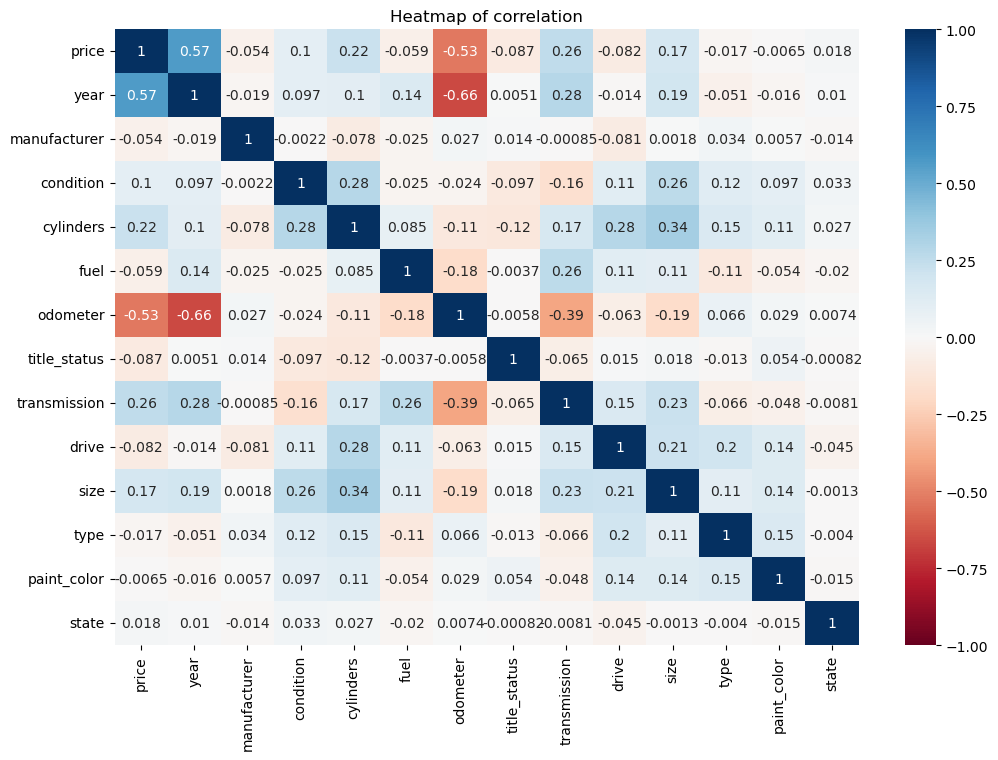

In [33]:
# create a heatmp of correlation
plt.figure(figsize=(12,8))
heatmap=sns.heatmap(df_encode.corr(), vmin=-1, vmax=1, annot=True, cmap='RdBu')
heatmap.set_title('Heatmap of correlation')

As is shown, the highest correlation involves year, odometer & price.

Other factors which has a correlation with price are transmission, cylinders, size and condition.

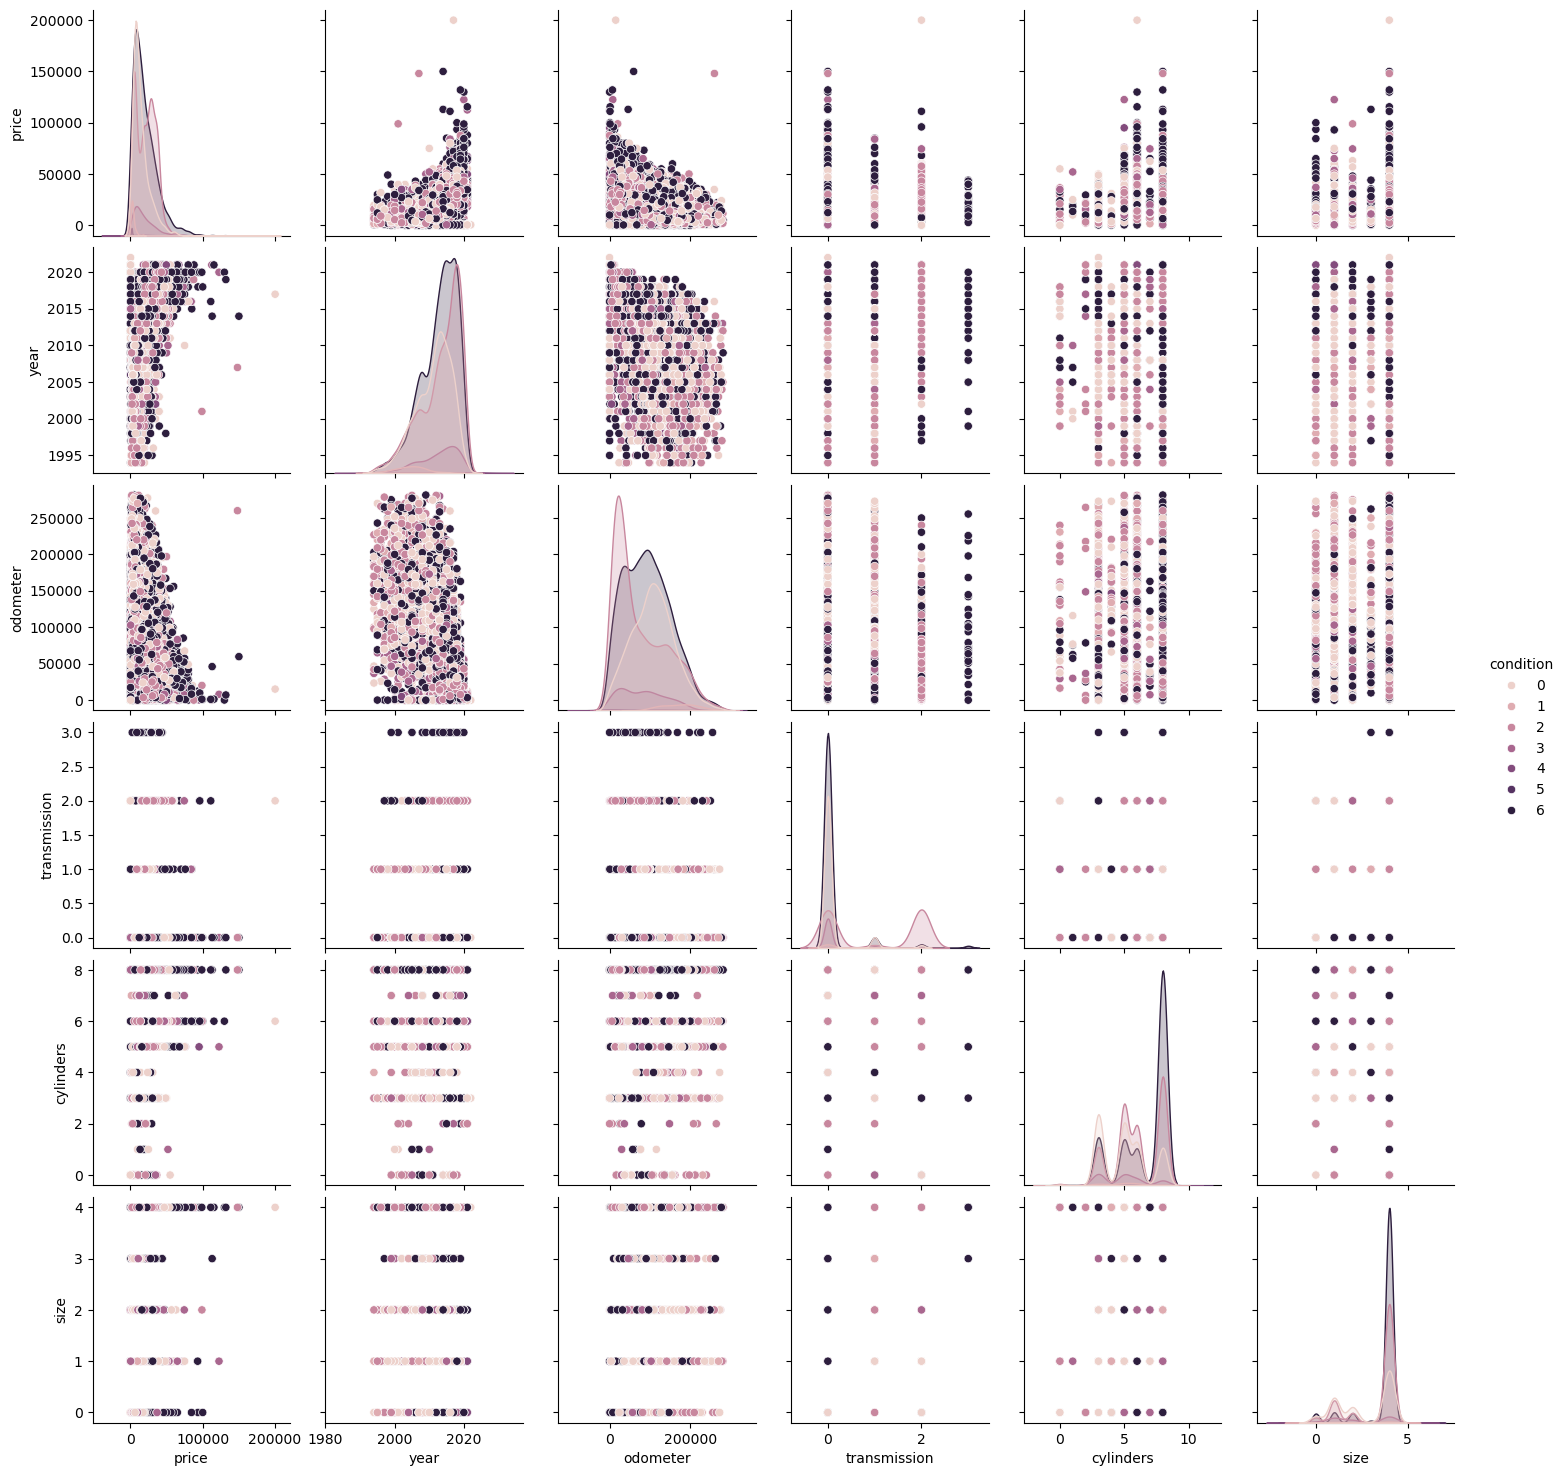

In [34]:
# for 'price','year','odometer','transmission','cylinders','size','condition' columns, perform a pairplot.
df_sample = df_encode[['price','year','odometer','transmission','cylinders','size','condition']]
df_sample = df_sample.sample(n=10000, random_state=42)
sns.pairplot(df_sample, hue='condition')

From the pairplot the samples, we can see the positive correlation between price and year 
as well as negative correlation between odometer and the year.  Other relations is hard to tell.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [35]:
# split the data into training data and development data using train_test_split
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

X= df_encode.drop(columns = ['price'])
y = df_encode['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)
X_train

,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
88170,2014.0,8,2,8,4,19579.0,0,2,2,4,9,9,7
131140,2017.0,28,6,8,2,45720.0,0,0,1,4,2,11,13
86605,2012.0,3,0,5,2,107999.0,0,1,0,4,11,9,6
214473,2016.0,16,0,3,2,69000.0,0,0,1,1,5,0,23
21192,2011.0,31,4,8,1,52396.0,0,0,1,2,4,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142744,2007.0,17,2,5,2,146000.0,0,0,1,2,11,1,14
304826,2015.0,7,0,8,2,131653.0,0,0,0,4,11,10,36
156388,2013.0,14,2,6,2,113000.0,0,0,0,1,10,9,12
173585,2010.0,6,6,8,2,143723.0,0,0,0,4,0,1,17


#### Linear Regression

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, mean_absolute_percentage_error


# build a linear pipeline for linear Regression
linear_pipe = Pipeline([('scaler', StandardScaler()),
                        ('linear', LinearRegression())])

# perform linear regression on the data
linear_pipe.fit(X_train, y_train)
train_predict=linear_pipe.predict(X_train)
test_predict = linear_pipe.predict(X_test)

# Regression Error
linear_train_mse = mean_squared_error(train_predict, y_train)
linear_test_mse = mean_squared_error(test_predict, y_test)
linear_train_mae = mean_absolute_error(train_predict, y_train)
linear_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
linear_coefs = linear_pipe.named_steps['linear'].coef_
print(linear_pipe)
print(linear_coefs)

print(f"Linear Model: train_mse ={linear_train_mse}, test_mse = {linear_test_mse}")
print(f"Linear Model: train_mae ={linear_train_mae}, test_mae = {linear_test_mae}")
print(linear_pipe.score(X_test, y_test))

Pipeline(steps=[('scaler', StandardScaler()), ('linear', LinearRegression())])
[ 5.35650828e+03 -6.25622891e+02  3.47876920e+02  2.47947029e+03
 -2.71819116e+03 -4.04858114e+03 -9.10446986e+02  1.21839394e+03
 -2.10618044e+03  2.94554786e+02  7.25201389e+01 -4.38072164e+00
  2.22530483e+01]
Linear Model: train_mse =121004164.37836777, test_mse = 119980138.5582291
Linear Model: train_mae =7779.89320889385, test_mae = 7749.570599668476
0.44511382803839195


In [43]:
# build a Polynomial degree 2 pipeline for Regression
Poly2_pipe = Pipeline([('scaler', StandardScaler()),
                       ('feature_transform', PolynomialFeatures(degree=2, include_bias=False)),
                        ('linear', LinearRegression())])

# perform Polynomial regression on the data
Poly2_pipe.fit(X_train, y_train)
train_predict=Poly2_pipe.predict(X_train)
test_predict = Poly2_pipe.predict(X_test)

# Regression Error
poly2_train_mse = mean_squared_error(train_predict, y_train)
poly2_test_mse = mean_squared_error(test_predict, y_test)
poly2_train_mae = mean_absolute_error(train_predict, y_train)
poly2_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
poly2_coefs = Poly2_pipe.named_steps['linear'].coef_
print(Poly2_pipe)
print(poly2_coefs)

print(f"Linear Model: train_mse ={poly2_train_mse}, test_mse = {poly2_test_mse}")
print(f"Linear Model: train_mae ={poly2_train_mae}, test_mae = {poly2_test_mae}")
print(Poly2_pipe.score(X_test, y_test))

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_transform', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])
[ 6.53714512e+03 -4.72021269e+02  2.76289789e+02  1.38179904e+01
 -2.13043034e+03 -4.28123212e+03 -2.40733890e+03 -1.30390181e+01
 -1.62240577e+03  9.45557057e+01 -8.49680340e+02  7.03992520e+02
 -1.20058928e+02  1.58270549e+03 -2.60818537e+02  4.87227077e+01
  9.63917554e+02 -8.52061864e+02 -4.30963795e+02 -2.70406697e+02
 -1.34801563e+03 -7.10221374e+02 -9.36174401e+01  3.75155500e+02
  3.59541028e+01  1.23293262e+02  2.72736456e+02 -4.95327429e+01
  4.74408823e+01 -6.77803893e+01  4.34998785e+02  2.45903677e+02
  1.18184626e+02 -1.23867317e+02  4.26211327e+01 -2.04135748e+02
 -3.88038739e+01  4.46708144e+01  1.94669940e+02  2.60556173e+02
 -3.85279541e+01 -3.96389372e+00  6.53296592e+01  1.42136699e+02
 -3.92055680e+02  1.17565896e+02  9.93908213e+00 -5.66951566e+01
  1.17608871e+02 -2.29583263e+03 -4.34149626e+

In [44]:
# build a Polynomial degree 3 pipeline for Regression
Poly3_pipe = Pipeline([('scaler', StandardScaler()),
                       ('feature_transform', PolynomialFeatures(degree=3, include_bias=False)),
                        ('linear', LinearRegression())])

# perform Polynomial regression on the data
Poly3_pipe.fit(X_train, y_train)
train_predict=Poly3_pipe.predict(X_train)
test_predict = Poly3_pipe.predict(X_test)

# Regression Error
poly3_train_mse = mean_squared_error(train_predict, y_train)
poly3_test_mse = mean_squared_error(test_predict, y_test)
poly3_train_mae = mean_absolute_error(train_predict, y_train)
poly3_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
poly3_coefs = Poly3_pipe.named_steps['linear'].coef_
print(Poly3_pipe)
print(poly3_coefs)

print(f"Linear Model: train_mse ={poly3_train_mse}, test_mse = {poly3_test_mse}")
print(f"Linear Model: train_mae ={poly3_train_mae}, test_mae = {poly3_test_mae}")
print(Poly3_pipe.score(X_test, y_test))

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_transform',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linear', LinearRegression())])
[ 5.81621441e+03 -2.52999843e+02  1.71449214e+03 -4.64484977e+02
 -1.24940077e+03 -4.81119326e+03  1.55234223e+03  2.73327772e+03
  6.53506668e+03  1.61688002e+03 -1.01001219e+03  4.19168445e+02
 -2.70286853e+01  1.23195939e+03 -3.99669989e+02  4.53414861e+00
  2.78174310e+02 -5.92079982e+02 -1.36518676e+03 -5.20411277e+02
 -1.79116607e+03 -9.02082415e+02 -3.45743424e+01  2.81285764e+02
  7.26395166e+01  1.10913302e+02  2.95163918e+02 -6.11981899e+01
 -4.12077284e+02 -1.65704524e+02  2.56593288e+02 -1.15776827e+02
 -1.94058158e+02 -6.97497492e+01 -4.85194397e+01  8.36686628e+01
 -1.50869366e+02  5.71455980e+00  6.62557246e+01  1.19380481e+02
  2.75580534e+02 -2.91261921e+02 -8.15029282e+02  4.73577031e+02
 -3.19943145e+02  9.81314901e+01 -4.63169456e+02 -1.10621759e+01
  3.01065091e+01 -5

In [47]:
# build a Polynomial degree 4 pipeline for Regression
Poly4_pipe = Pipeline([('scaler', StandardScaler()),
                       ('feature_transform', PolynomialFeatures(degree=4, include_bias=False)),
                        ('linear', LinearRegression())])

# perform Polynomial regression on the data
Poly4_pipe.fit(X_train, y_train)
train_predict=Poly4_pipe.predict(X_train)
test_predict = Poly4_pipe.predict(X_test)

# Regression Error
poly4_train_mse = mean_squared_error(train_predict, y_train)
poly4_test_mse = mean_squared_error(test_predict, y_test)
poly4_train_mae = mean_absolute_error(train_predict, y_train)
poly4_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
poly4_coefs = Poly4_pipe.named_steps['linear'].coef_
print(Poly4_pipe)
print(poly4_coefs)

print(f"Linear Model: train_mse ={poly4_train_mse}, test_mse = {poly4_test_mse}")
print(f"Linear Model: train_mae ={poly4_train_mae}, test_mae = {poly4_test_mae}")
print(Poly4_pipe.score(X_test, y_test))

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_transform',
                 PolynomialFeatures(degree=4, include_bias=False)),
                ('linear', LinearRegression())])
[ 4389.25487357  -924.92873958 -3931.76978168 ...    80.84334716
    89.91143053   154.08288724]
Linear Model: train_mse =60040499.834315576, test_mse = 60557064.89312694
Linear Model: train_mae =4896.97179896897, test_mae = 4914.824815589596
0.7199346631236807


In [94]:
# build a Polynomial degree 5 pipeline for Regression
Poly5_pipe = Pipeline([('scaler', StandardScaler()),
                       ('feature_transform', PolynomialFeatures(degree=5, include_bias=False)),
                        ('linear', LinearRegression())])

# perform Polynomial regression on the data
Poly5_pipe.fit(X_train, y_train)
train_predict=Poly5_pipe.predict(X_train)
test_predict = Poly5_pipe.predict(X_test)

# Regression Error
poly5_train_mse = mean_squared_error(train_predict, y_train)
poly5_test_mse = mean_squared_error(test_predict, y_test)
poly5_train_mae = mean_absolute_error(train_predict, y_train)
poly5_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
poly5_coefs = poly5_pipe.named_steps['linear'].coef_
print(Poly5_pipe)
print(poly5_coefs)

print(f"Linear Model: train_mse ={poly5_train_mse}, test_mse = {poly5_test_mse}")
print(f"Linear Model: train_mae ={poly5_train_mae}, test_mae = {poly5_test_mae}")
print(Poly5_pipe.score(X_test, y_test))

MemoryError: Unable to allocate 16.1 GiB for an array with shape (252595, 8567) and data type float64

### Summary of Polynomial Regression
We have performed Linear regression, degree 2, degree 3, degree 4 and degress 5 Polynomial regression.  The testing error (mean_squared_error and mean_absolute_error) is reducing as degree increases.  However it takes more time for higher degree Polynomial regression.  Degree 4 regression took about 5 mins to finish.  Degree 5 regression was unsuccessful after 20 min and aborted with memery error.
Therefore, we will focus on degree 3 polynomial for Lasso and Ridge regression.

In [53]:
# We now try using lasso to offer a penalized regression method
Lasso3_pipe = Pipeline([('scaler', StandardScaler()),
                       ('feature_transform', PolynomialFeatures(degree=3, include_bias=False)),
                        ('lasso', Lasso())])

# perform Polynomial regression on the data
Lasso3_pipe.fit(X_train, y_train)
train_predict=Lasso3_pipe.predict(X_train)
test_predict = Lasso3_pipe.predict(X_test)

# Regression Error
Lasso3_train_mse = mean_squared_error(train_predict, y_train)
Lasso3_test_mse = mean_squared_error(test_predict, y_test)
Lasso3_train_mae = mean_absolute_error(train_predict, y_train)
Lasso3_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
Lasso3_coefs = Lasso3_pipe.named_steps['lasso'].coef_
print(Lasso3_pipe)
print(Lasso3_coefs)

print(f"Lasso Degree 3 Model: train_mse ={Lasso3_train_mse}, test_mse = {Lasso3_test_mse}")
print(f"Lasso Degree 3 Model: train_mae ={Lasso3_train_mae}, test_mae = {Lasso3_test_mae}")
print(Lasso3_pipe.score(X_test, y_test))

C:\Users\JPM\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.859e+12, tolerance: 5.502e+09
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_transform',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('lasso', Lasso())])
[ 5.82092994e+03 -1.87119355e+02  1.50855296e+03 -3.01224968e+02
 -1.13249100e+03 -4.77362747e+03 -6.80098969e+02  2.53396450e+03
  6.45143006e+03  1.39744062e+03 -9.54070281e+02  3.68824740e+02
 -1.78444776e+01  1.24029427e+03 -3.95875045e+02  0.00000000e+00
  2.66294413e+02 -5.93090608e+02 -1.34488008e+03 -5.08234884e+02
 -1.78156362e+03 -8.95751988e+02 -3.23093844e+00  2.64482202e+02
  5.71002878e+01  1.02287357e+02  2.93061947e+02 -5.23757560e+01
 -4.07813271e+02 -1.64021964e+02  2.58631395e+02 -5.42452045e+01
 -1.50837945e+02 -7.13143579e+01 -5.01429603e+01  7.92153479e+01
 -1.47506342e+02  6.11831782e+00  1.22364767e+02  1.31021568e+02
  2.75111219e+02 -2.82872401e+02 -7.90434891e+02  3.97361092e+02
 -3.21712192e+02  9.31106969e+01 -4.54365352e+02 -1.76115768e+01
  2.59697157e+01 -5.09505325e+0

In [52]:
# We now try using Ridge to offer a penalized regression method
Ridge3_pipe = Pipeline([('scaler', StandardScaler()),
                       ('feature_transform', PolynomialFeatures(degree=3, include_bias=False)),
                        ('ridge', Ridge())])

# perform Polynomial regression on the data
Ridge3_pipe.fit(X_train, y_train)
train_predict=Ridge3_pipe.predict(X_train)
test_predict = Ridge3_pipe.predict(X_test)

# Regression Error
Ridge3_train_mse = mean_squared_error(train_predict, y_train)
Ridge3_test_mse = mean_squared_error(test_predict, y_test)
Ridge3_train_mae = mean_absolute_error(train_predict, y_train)
Ridge3_test_mae = mean_absolute_error(test_predict, y_test)

# check the model and results
Ridge3_coefs = Ridge3_pipe.named_steps['ridge'].coef_
print(Ridge3_pipe)
print(Ridge3_coefs)

print(f"Ridge degree 3 Model: train_mse ={Ridge3_train_mse}, test_mse = {Ridge3_test_mse}")
print(f"Ridge degree 3 Model: train_mae ={Ridge3_train_mae}, test_mae = {Ridge3_test_mae}")
print(Ridge3_pipe.score(X_test, y_test))

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_transform',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('ridge', Ridge())])
[ 5.81546231e+03 -2.53085010e+02  1.71324211e+03 -4.63846565e+02
 -1.24871667e+03 -4.81113458e+03  1.54688879e+03  2.73169818e+03
  6.53283716e+03  1.61601827e+03 -1.00974374e+03  4.19246784e+02
 -2.70738084e+01  1.23196779e+03 -3.99680962e+02  4.50280241e+00
  2.78139534e+02 -5.92053194e+02 -1.36512253e+03 -5.20727782e+02
 -1.79137842e+03 -9.02109055e+02 -3.45644485e+01  2.81325219e+02
  7.26886823e+01  1.10921609e+02  2.95141394e+02 -6.11897195e+01
 -4.12069054e+02 -1.65692664e+02  2.56601075e+02 -1.15726007e+02
 -1.94008660e+02 -6.97993961e+01 -4.85113689e+01  8.36915229e+01
 -1.50863494e+02  5.71654695e+00  6.66886837e+01  1.19415658e+02
  2.75590012e+02 -2.91246971e+02 -8.15083641e+02  4.73336318e+02
 -3.19984154e+02  9.81326242e+01 -4.63164770e+02 -1.10607747e+01
  3.00984771e+01 -5.10103888e+0

### Summary of Linear, Lasso, Ridge Regression Comparison
With the degree 3 Polynomial transformation, we did Linear regression, Lasso regression and Ridge regression.  The results are very similar.  For this issue, there is no much difference for the three methods.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [55]:
# Grid search Ridge
parameter_dict = {'ridge__alpha': [0.1, 1, 10, 100, 100]}
Opt_Ridge3 = GridSearchCV(Ridge3_pipe, param_grid = parameter_dict)
Opt_Ridge3.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('feature_transform',
                                        PolynomialFeatures(degree=3,
                                                           include_bias=False)),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.1, 1, 10, 100, 100]})

In [60]:
train_predict = Opt_Ridge3.predict(X_train)
test_predict = Opt_Ridge3.predict(X_test)

best_alpha = Opt_Ridge3.best_params_
print(f"Best alpha is: {best_alpha}")

Best alpha is: {'ridge__alpha': 10}


In [63]:
Optimal_Ridge_Pipeline =  Pipeline([('scaler', StandardScaler()),
                     ('feature_transform', PolynomialFeatures(degree=3, include_bias=False)),
                       ('ridge', Ridge(alpha = best_alpha['ridge__alpha']))])

Ridge_final = Optimal_Ridge_Pipeline.fit(X_train, y_train)
train_predict=Ridge_final.predict(X_train)
test_predict=Ridge_final.predict(X_test)


#Regression Error
Ridge_Final_train_mse = mean_squared_error(train_predict, y_train)
Ridge_Final_test_mse = mean_squared_error(test_predict, y_test)
Ridge_Final_train_mae = mean_absolute_error(train_predict, y_train)
Ridge_Final_test_mae = mean_absolute_error(test_predict, y_test)



#Check
print(f"Opt_Ridge Degree 3 Model: train_mse={Ridge_Final_train_mse}, test_mse={Ridge_Final_test_mse}")
print(f"Opt_Ridge Degree 3 Model: train_mae={Ridge_Final_train_mae}, test_mae={Ridge_Final_test_mae}")
print(Ridge_final.score(X_test, y_test))

Opt_Ridge Degree 3 Model: train_mse=69732459.54616477, test_mse=69186886.29193823
Opt_Ridge Degree 3 Model: train_mae=5347.0856394927405, test_mae=5325.772943335974
0.6800233193109316


The best alpha is 10.  However compared with the default value (aplha=1), there is not much difference in the MSE and MAE.

In [70]:
# use Permutation importance for selecting features
from sklearn.inspection import permutation_importance

r = permutation_importance(Optimal_Ridge_Pipeline, X_test, y_test, n_repeats=25, random_state=42)
feature_importance_poly3 = {}
for i in r.importances_mean.argsort()[::-1]:
    print(f"{X_test.columns[i]:<8}" f"{r.importances_mean[i]:.3f}"  f" +/- {r.importances_std[i]:.3f}")
    feature_importance_poly3[X_test.columns[i]]=r.importances_mean[i]
        

year    0.371 +/- 0.003
odometer0.141 +/- 0.001
fuel    0.129 +/- 0.001
cylinders0.128 +/- 0.001
drive   0.109 +/- 0.001
size    0.073 +/- 0.001
transmission0.035 +/- 0.000
title_status0.028 +/- 0.001
condition0.026 +/- 0.001
type    0.026 +/- 0.001
manufacturer0.010 +/- 0.000
paint_color0.008 +/- 0.000
state   0.005 +/- 0.000


With permutation importance we can see that "year" is the best feature to predict the price variation.
2nd most significant factor is "odometer".  Other important features include "fuel", "cylinders" and "drive".

In [71]:
feature_importance_poly3 = pd.DataFrame(feature_importance_poly3,index=[0]).T
feature_importance_poly3 = feature_importance_poly3.rename(columns={0: "Feature Importance for Polynomial Degree 3"})
feature_importance_poly3

,Feature Importance for Polynomial Degree 3
year,0.370523
odometer,0.141128
fuel,0.129477
cylinders,0.127844
drive,0.109259
size,0.072534
transmission,0.035444
title_status,0.027915
condition,0.026427
type,0.025966


Text(0.5, 1.0, 'Polynomial Degree 3 Ridge model Feature Importance')

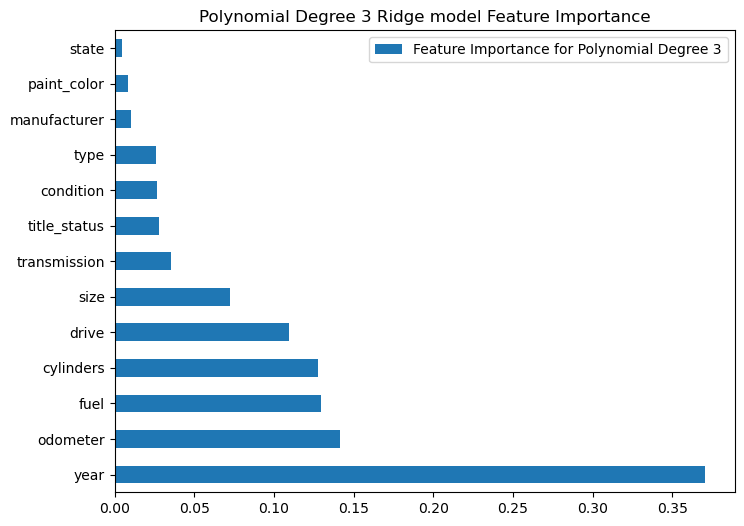

In [74]:
feature_importance_poly3.plot.barh(figsize=(8,6))
plt.title("Polynomial Degree 3 Ridge model Feature Importance")

As shown in the feature importance plot, the top six most important attributes that impacting the price of cars are:
1. year
2. odometer
3. fuel
4. cylinders
5. drive
6. size
There are limits on this model.  From the business point of view, it does not tell the profitability of the car.  A car of high value does not necessarily mean high profitability.  For the business objective, a profitability model would include the trade-in value, a dealer selling price, turn around period etc.
There are area to improve this model.  Logarithmic transformation may yield more accurate result for inference tha a polynomial model.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

to maximize the price of a car, the dealer should focus on the following factors in the order of importance:
1. year  (newer car the higher price)
2. odometer  (less reading the higher price)
3. fuel   (gas is higher price)
4. cylinders  (bigger engineer the higher price)
5. drive   
6. size

Text(0.5, 1.0, 'Polynomial Degree 3 Ridge model Feature Importance')

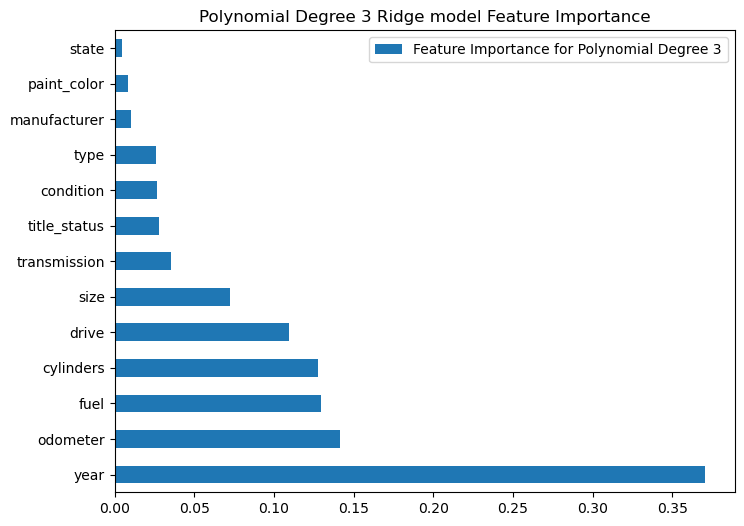

In [76]:
feature_importance_poly3.plot.barh(figsize=(8,6))
plt.title("Polynomial Degree 3 Ridge model Feature Importance")

There are limits on this model.  From the business point of view, it does not tell the profitability of the car.  A car of high value does not necessarily mean high profitability.  For the business objective, a profitability model would include the trade-in value, a dealer selling price, turn around period etc.
There are area to improve this model.  Logarithmic transformation may yield more accurate result for inference tha a polynomial model.